EDA inicial del dataset de tuits – Elecciones Colombia 2026

0. Imports y carga del dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re
import unicodedata
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\juanp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
df = pd.read_csv("../data/processed/tweets_clean.csv")
df.head()

,id,author,text,created_at,lang,source,clean_text
0,IvanCepeda_0,desconocido,¿Por qué le da tanto susto a #IvánCepeda senta...,2025-11-19 19:10:01,es,#IvanCepeda,por qué le da tanto susto a sentarse frente a ...
1,IvanCepeda_1,desconocido,#IvánCepeda toma la delantera en la carrera pr...,2025-11-19 19:10:01,es,#IvanCepeda,toma la delantera en la carrera presidencial y...
2,IvanCepeda_2,desconocido,El exgobernador Zuluaga anunció este 19 de nov...,2025-11-19 19:10:01,es,#IvanCepeda,el exgobernador zuluaga anunció este 19 de nov...
3,IvanCepeda_3,desconocido,#IvanCepeda: El senador pudiera ser uno de los...,2025-11-19 19:10:01,es,#IvanCepeda,el senador pudiera ser uno de los candidatos e...
4,IvanCepeda_4,desconocido,#IvánCepeda es hoy el candidato presidencial c...,2025-11-19 19:10:01,es,#IvanCepeda,es hoy el candidato presidencial con mayor int...


1. Tokenización

In [3]:
# stopwords base
stopwords_es = set(stopwords.words("spanish"))

# stopwords adicionales para Twitter
extra_stops = {
    "rt","via","com","tco","co","amp",
    "https","http","www",
    "si","asi","solo","aun",
    "mas","muy","tan",
    "sr","sra","ud","uds",
    "del","al",
    "pues","entonces","ahi","aqui","aca",
    "donde","cuando","porque",
    "esto","esta","ese","esa",
    "aquel","aquella",
    "colombia"
}

stopwords_total = stopwords_es.union(extra_stops)

def tokenize_pro(text: str):
    text = unicodedata.normalize("NFKD", text).encode("ascii","ignore").decode("utf-8")
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+"," ",text)
    text = re.sub(r"@\w+"," ",text)
    text = text.replace("#"," ")
    text = re.sub(r"[^a-zñáéíóúü ]"," ",text)
    tokens = text.split()

    tokens = [
        t for t in tokens
        if t not in stopwords_total
        and len(t) > 3
        and not t.isnumeric()
    ]

    return tokens

df["tokens"] = df["clean_text"].astype(str).apply(tokenize_pro)
df.head()


,id,author,text,created_at,lang,source,clean_text,tokens
0,IvanCepeda_0,desconocido,¿Por qué le da tanto susto a #IvánCepeda senta...,2025-11-19 19:10:01,es,#IvanCepeda,por qué le da tanto susto a sentarse frente a ...,"[susto, sentarse, frente, abelardo, bandidos, ..."
1,IvanCepeda_1,desconocido,#IvánCepeda toma la delantera en la carrera pr...,2025-11-19 19:10:01,es,#IvanCepeda,toma la delantera en la carrera presidencial y...,"[toma, delantera, carrera, presidencial, refue..."
2,IvanCepeda_2,desconocido,El exgobernador Zuluaga anunció este 19 de nov...,2025-11-19 19:10:01,es,#IvanCepeda,el exgobernador zuluaga anunció este 19 de nov...,"[exgobernador, zuluaga, anuncio, noviembre, re..."
3,IvanCepeda_3,desconocido,#IvanCepeda: El senador pudiera ser uno de los...,2025-11-19 19:10:01,es,#IvanCepeda,el senador pudiera ser uno de los candidatos e...,"[senador, pudiera, candidatos, proximas, elecc..."
4,IvanCepeda_4,desconocido,#IvánCepeda es hoy el candidato presidencial c...,2025-11-19 19:10:01,es,#IvanCepeda,es hoy el candidato presidencial con mayor int...,"[candidato, presidencial, mayor, intencion, vo..."


2. Estadísticas básicas del dataset

In [4]:
print("Tweets totales:", len(df))
print("Fecha mínima:", df["created_at"].min())
print("Fecha máxima:", df["created_at"].max())
print("Fuentes capturadas:", df["source"].nunique())
df.describe(include="all")


Tweets totales: 2100
Fecha mínima: 2025-11-19 19:10:01
Fecha máxima: 2025-11-21 15:44:38
Fuentes capturadas: 34


,id,author,text,created_at,lang,source,clean_text,tokens
count,2100,2100,2100,2100,2100,2100,2100,2100
unique,2100,1,2100,40,1,34,2100,2092
top,IvanCepeda_0,desconocido,¿Por qué le da tanto susto a #IvánCepeda senta...,2025-11-19 19:12:46,es,#MurilloPresidente,por qué le da tanto susto a sentarse frente a ...,"[dias, acabe, gobierno, pesar, inventaron, exa..."
freq,1,2100,1,99,2100,99,1,4


3. Distribución temporal

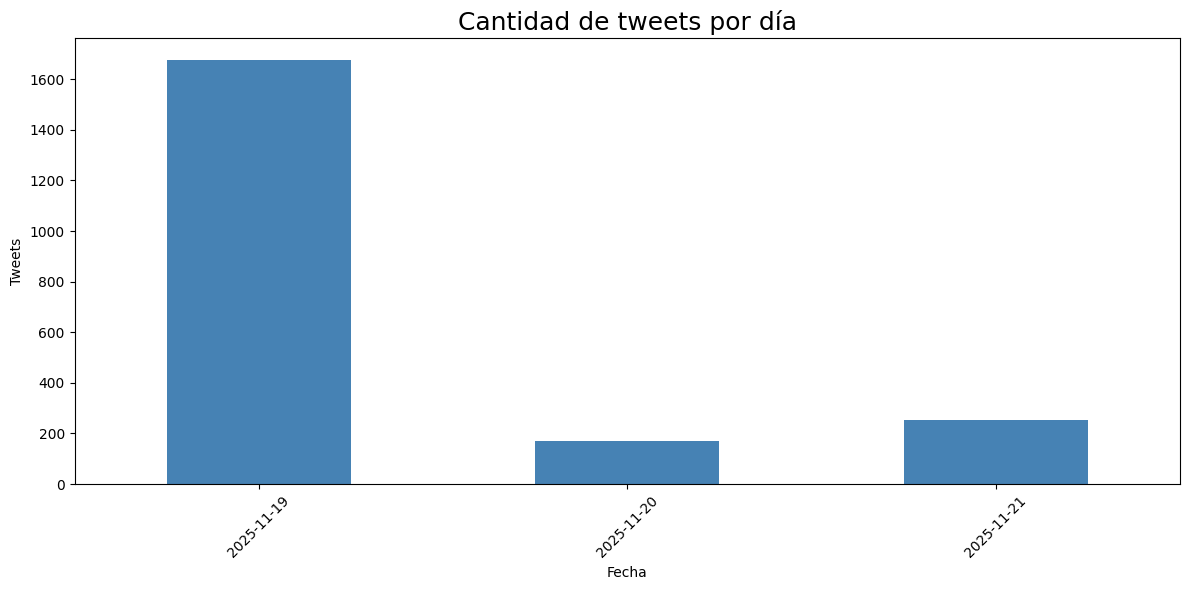

In [5]:
df["created_date"] = pd.to_datetime(df["created_at"]).dt.date

plt.figure(figsize=(12,6))
df.groupby("created_date").size().plot(kind="bar", color="steelblue")
plt.title("Cantidad de tweets por día", fontsize=18)
plt.xlabel("Fecha")
plt.ylabel("Tweets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


4. Top palabras (tokens)

In [6]:
all_tokens = df["tokens"].sum()
freq = Counter(all_tokens).most_common(30)
freq_df = pd.DataFrame(freq, columns=["word","freq"])
freq_df


,word,freq
0,petro,246
1,presidente,197
2,pais,165
3,polo,118
4,uribe,117
5,presidencial,101
6,gobierno,99
7,youtu,90
8,gustavo,86
9,candidato,84


Gráfico de barras

C:\Users\juanp\AppData\Local\Temp\ipykernel_13652\1651265627.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=freq_df, y="word", x="freq", palette="Blues_r")


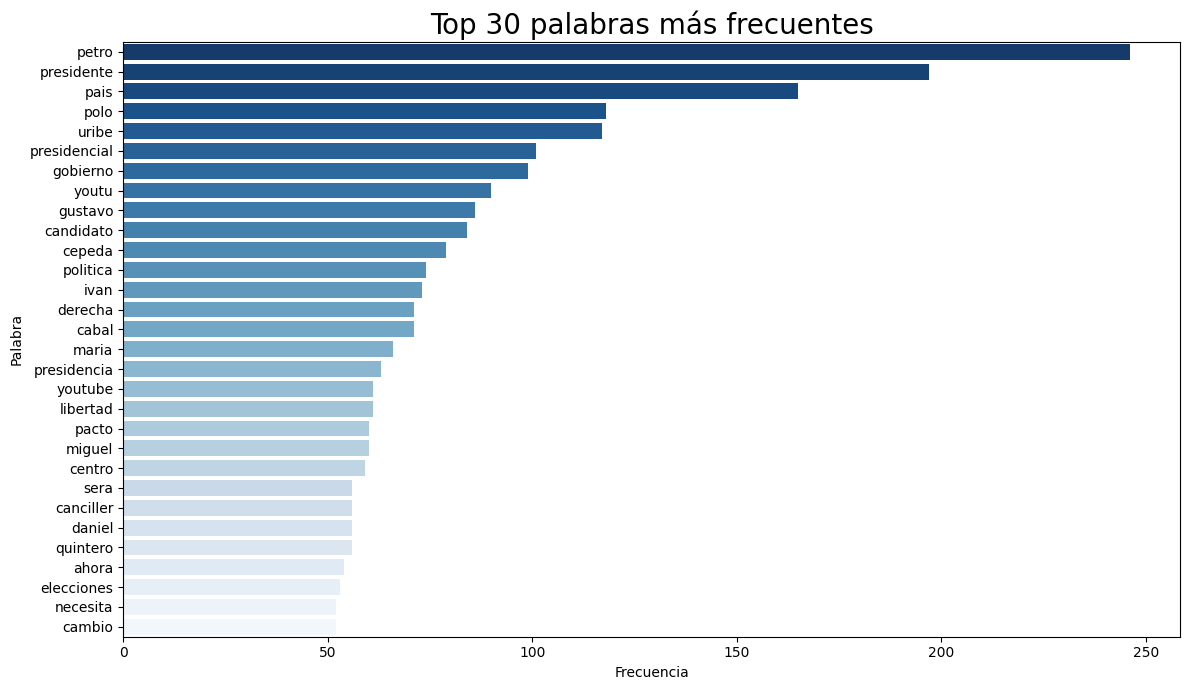

In [7]:
plt.figure(figsize=(12,7))
sns.barplot(data=freq_df, y="word", x="freq", palette="Blues_r")
plt.title("Top 30 palabras más frecuentes", fontsize=20)
plt.xlabel("Frecuencia")
plt.ylabel("Palabra")
plt.tight_layout()
plt.show()


5. Wordcloud general con tokens

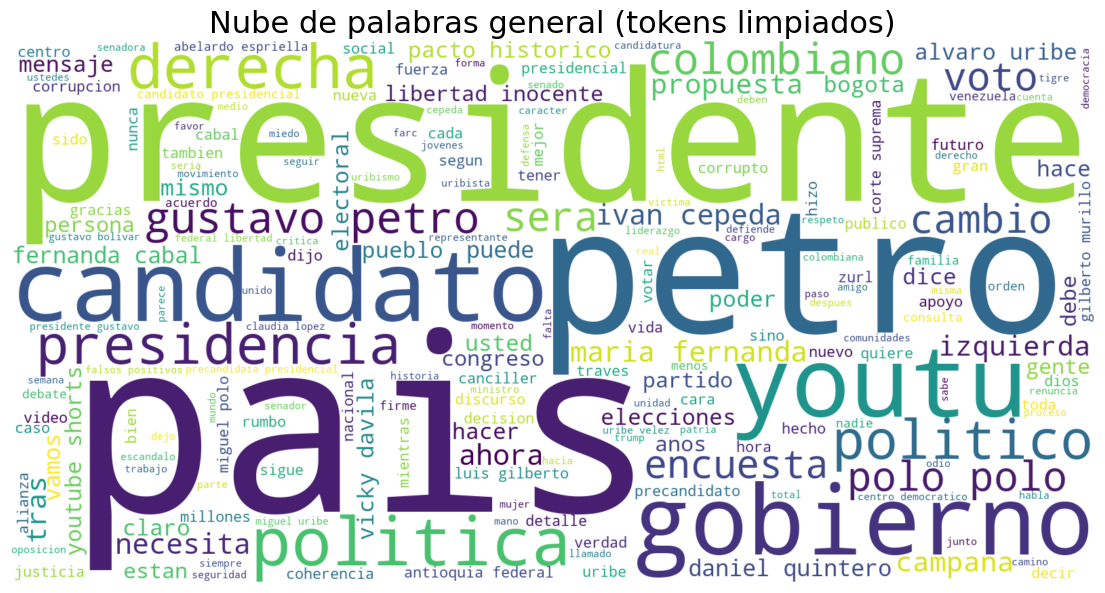

In [8]:
text = " ".join(all_tokens)

wc = WordCloud(
    width=1600,
    height=800,
    background_color="white",
    colormap="viridis"
).generate(text)

plt.figure(figsize=(14,8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras general (tokens limpiados)", fontsize=22)
plt.show()


In [9]:
candidate_sources = {
    "Iván Cepeda": ["#IvanCepeda","#CepedaPresidente","#Cepeda"],
    "Luis Gilberto Murillo": ["#LuisGilbertoMurillo","#MurilloPresidente","#Murillo2026"],
    "María Fernanda Cabal": ["#MariaFernandaCabal","#CabalPresidenta","#Cabal","#Cabal2026"],
    "Claudia López": ["#ClaudiaLopez","#LopezPresidenta","#ClaudiaLopez2026"],
    "Gustavo Bolívar": ["#GustavoBolivar","#BolivarPresidente","#Bolivar2026"],
    "Andrés Guerra": ["#AndresGuerra","#AndresGuerra2026"],
    "Gustavo Petro": ["#Petro","#GustavoPetro","#PetroColombia"],
}


7. Wordcloud por candidato (mosaico)

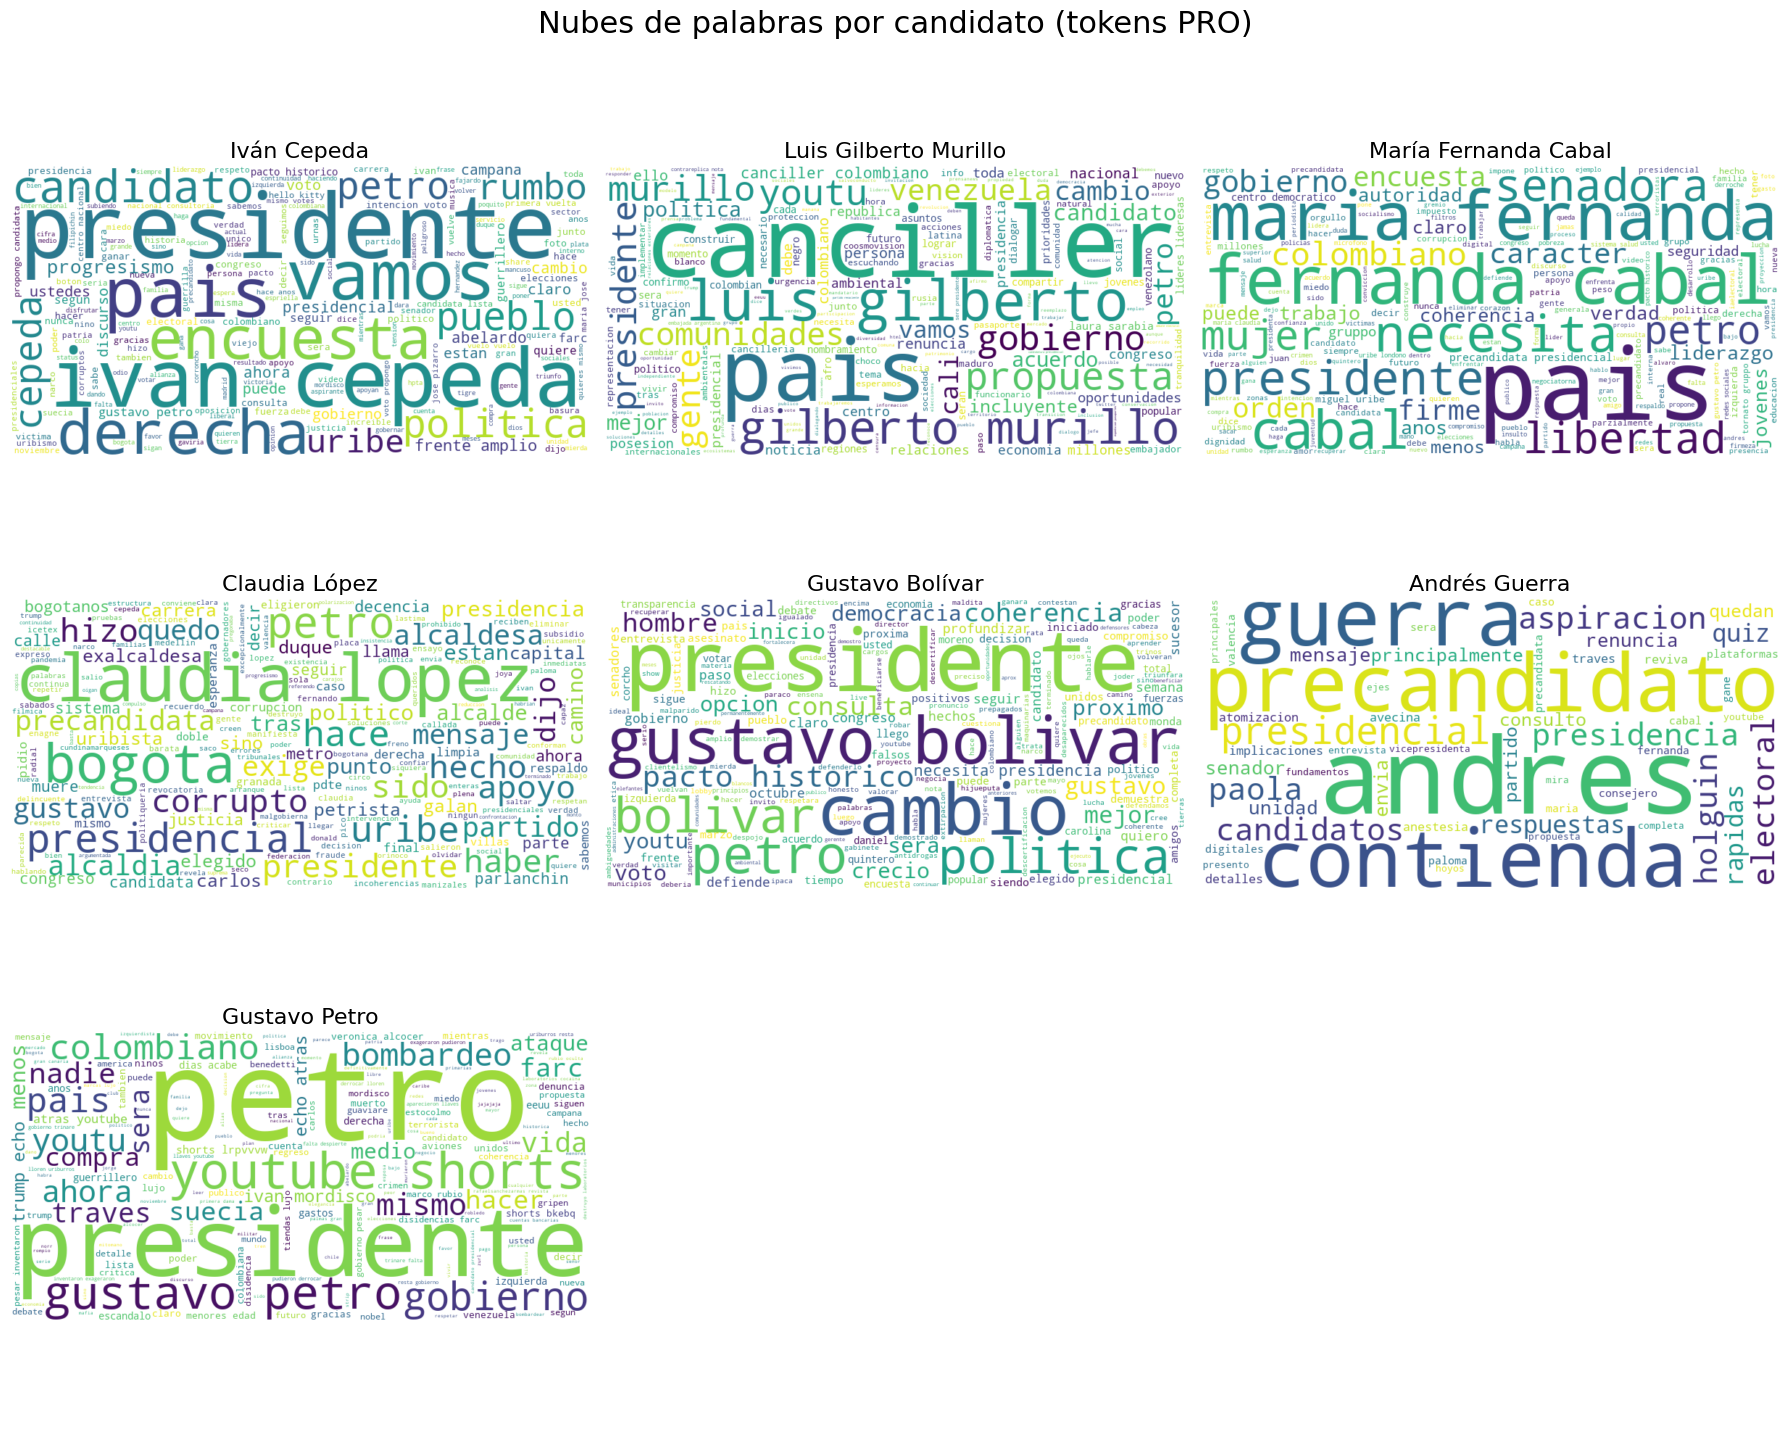

In [10]:
import math

def plot_wordclouds_by_candidate(df, candidate_sources_dict):
    n = len(candidate_sources_dict)
    cols = 3
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(18, 5*rows))
    axes = axes.flatten()

    for i, (cand, sources) in enumerate(candidate_sources_dict.items()):
        ax = axes[i]

        dff = df[df["source"].isin(sources)]
        tokens = dff["tokens"].sum()
        text = " ".join(tokens)

        if len(tokens) == 0:
            ax.set_title(f"{cand}\n(Sin datos)")
            ax.axis("off")
            continue
        
        wc = WordCloud(
            width=800,
            height=400,
            background_color="white",
            colormap="viridis"
        ).generate(text)

        ax.imshow(wc, interpolation="bilinear")
        ax.set_title(cand, fontsize=16)
        ax.axis("off")

    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Nubes de palabras por candidato (tokens PRO)", fontsize=22, y=0.95)
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

plot_wordclouds_by_candidate(df, candidate_sources)


8. Frecuencia de palabras por candidato

In [11]:
freq_cand = {}

for cand, sources in candidate_sources.items():
    tokens = df[df["source"].isin(sources)]["tokens"].sum()
    freq_cand[cand] = Counter(tokens).most_common(15)

freq_cand


{'Iván Cepeda': [('cepeda', 40),
  ('presidente', 35),
  ('ivan', 34),
  ('petro', 20),
  ('pais', 20),
  ('vamos', 20),
  ('derecha', 16),
  ('candidato', 13),
  ('voto', 13),
  ('politica', 13),
  ('frente', 12),
  ('pueblo', 12),
  ('rumbo', 11),
  ('pacto', 11),
  ('uribe', 11)],
 'Luis Gilberto Murillo': [('canciller', 55),
  ('murillo', 48),
  ('pais', 35),
  ('luis', 32),
  ('gilberto', 31),
  ('presidente', 21),
  ('youtu', 18),
  ('gobierno', 17),
  ('gente', 15),
  ('comunidades', 14),
  ('venezuela', 13),
  ('petro', 12),
  ('propuestas', 12),
  ('colombiano', 11),
  ('cali', 10)],
 'María Fernanda Cabal': [('cabal', 59),
  ('maria', 44),
  ('pais', 38),
  ('fernanda', 38),
  ('necesita', 20),
  ('presidente', 19),
  ('petro', 19),
  ('senadora', 18),
  ('libertad', 17),
  ('presidencial', 15),
  ('uribe', 15),
  ('mujer', 15),
  ('gruppo', 15),
  ('precandidata', 14),
  ('gobierno', 13)],
 'Claudia López': [('claudia', 20),
  ('lopez', 20),
  ('bogota', 12),
  ('petro', 7),

C:\Users\juanp\AppData\Local\Temp\ipykernel_13652\2571679176.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[i], data=df_tmp, y="word", x="freq", palette="viridis")
C:\Users\juanp\AppData\Local\Temp\ipykernel_13652\2571679176.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[i], data=df_tmp, y="word", x="freq", palette="viridis")
C:\Users\juanp\AppData\Local\Temp\ipykernel_13652\2571679176.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[i], data=df_tmp, y="word", x="freq", palette="viridis")
C:\Users\juanp\A

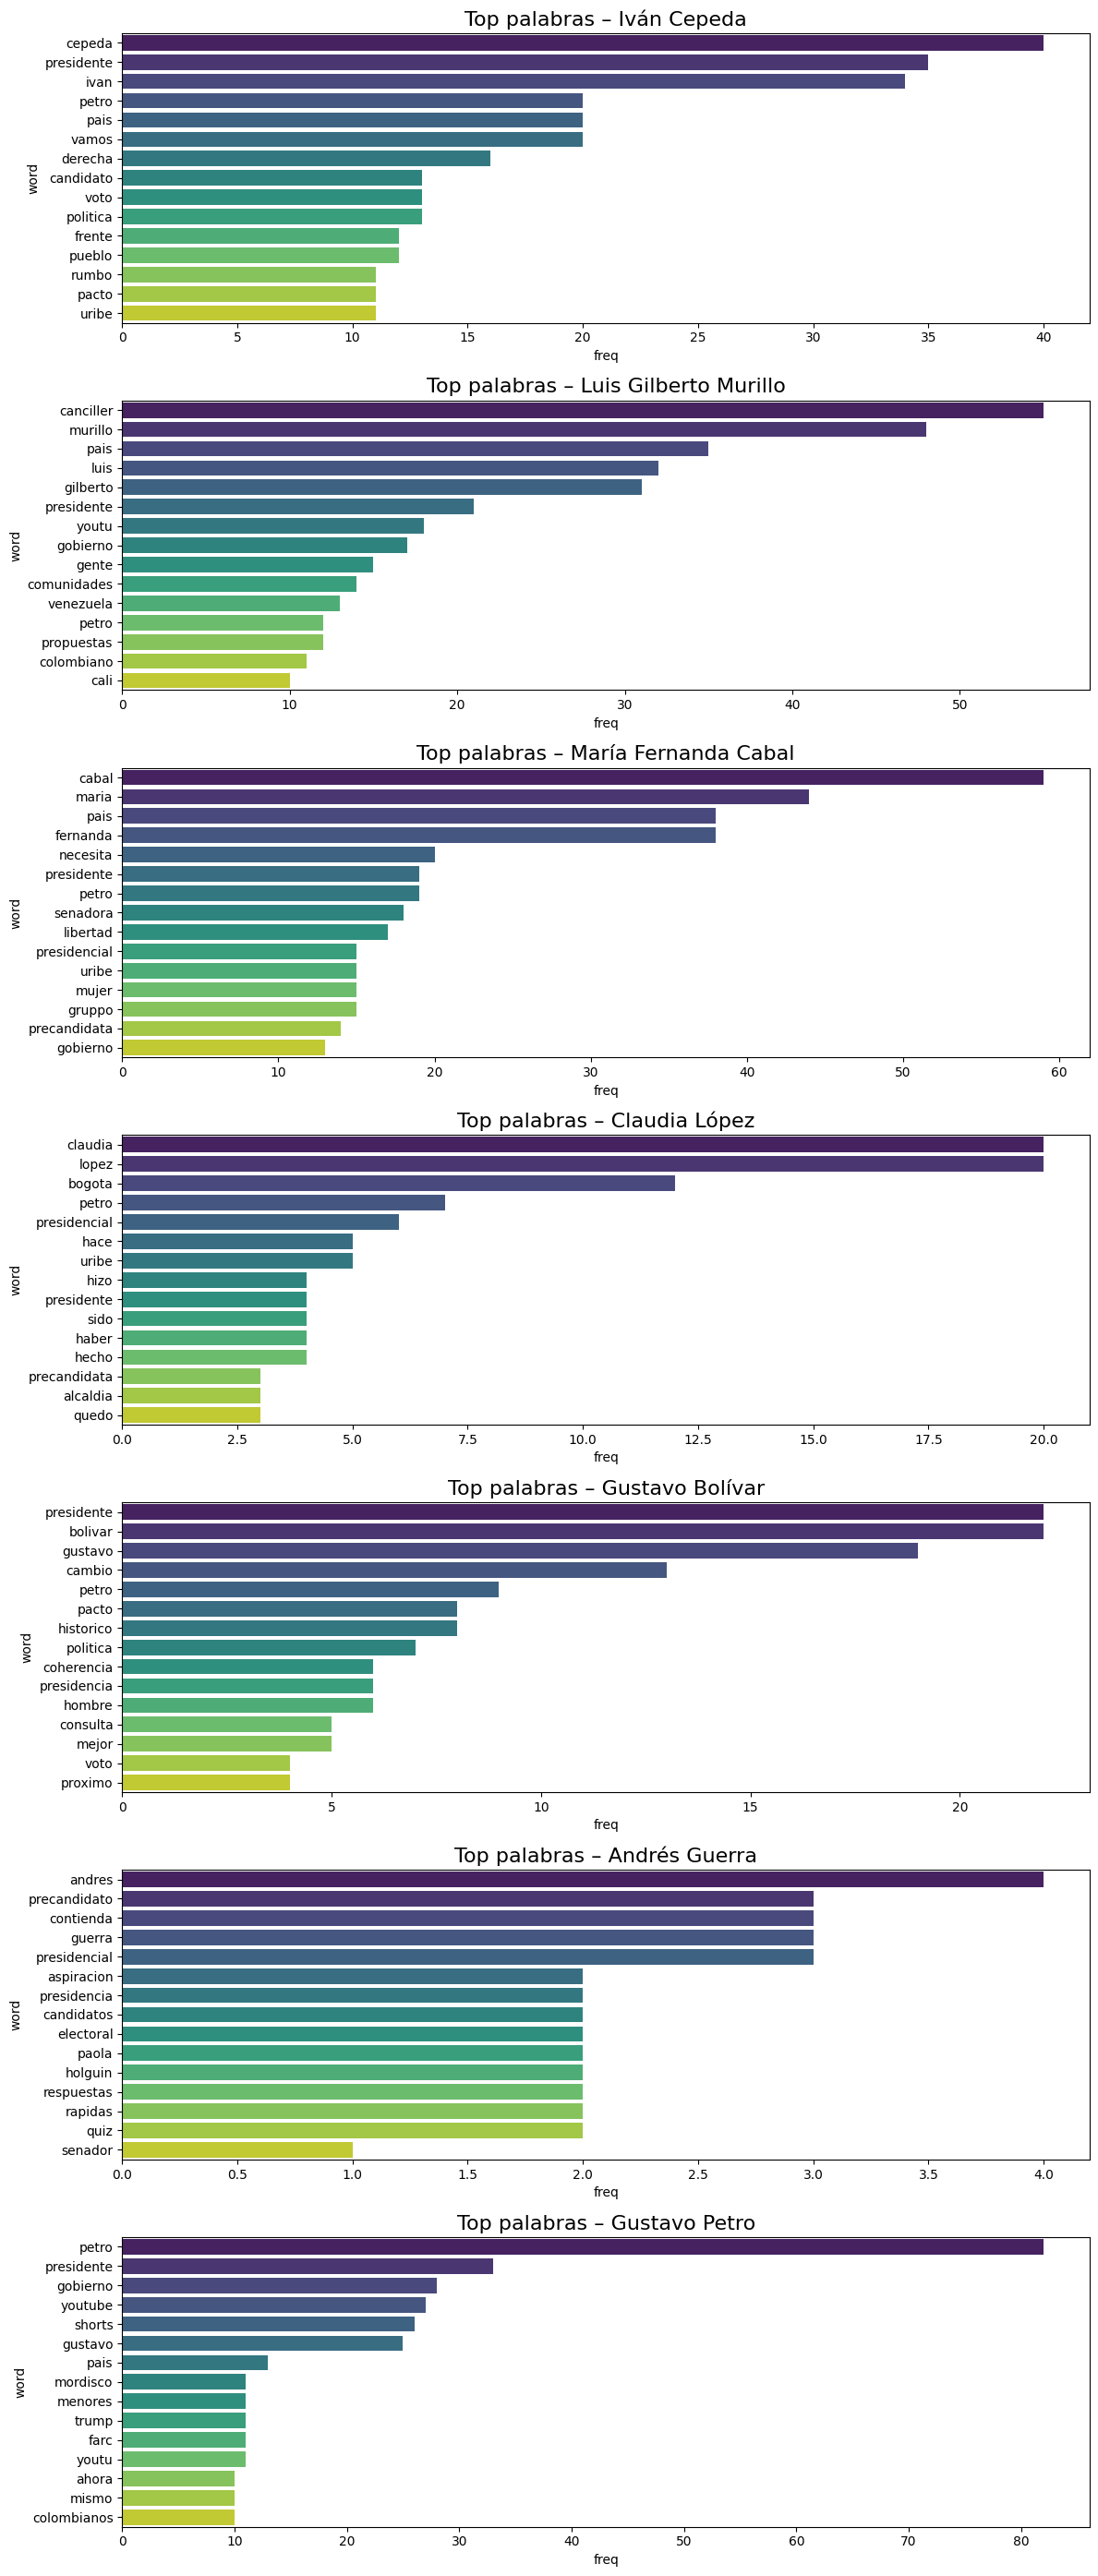

In [12]:
fig, axes = plt.subplots(len(freq_cand), 1, figsize=(12, 4*len(freq_cand)))

for i, (cand, words) in enumerate(freq_cand.items()):
    df_tmp = pd.DataFrame(words, columns=["word","freq"])
    sns.barplot(ax=axes[i], data=df_tmp, y="word", x="freq", palette="viridis")
    axes[i].set_title(f"Top palabras – {cand}", fontsize=16)

plt.tight_layout()
plt.show()


9. Bigramas / Trigramas (MUY ÚTIL)

In [13]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2,3), min_df=2)
X = vectorizer.fit_transform(df["clean_text"].astype(str))

ngrams = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1

top_ngrams = pd.DataFrame({
    "ngram": ngrams,
    "freq": counts
}).sort_values("freq", ascending=False).head(20)

top_ngrams


,ngram,freq
1396,de la,343
2541,en el,194
2596,en la,154
1470,de los,109
4380,lo que,96
1447,de las,92
7420,youtu be,90
1270,de colombia,86
5020,no se,74
897,con el,72


10. Heatmap comparativo entre candidatos

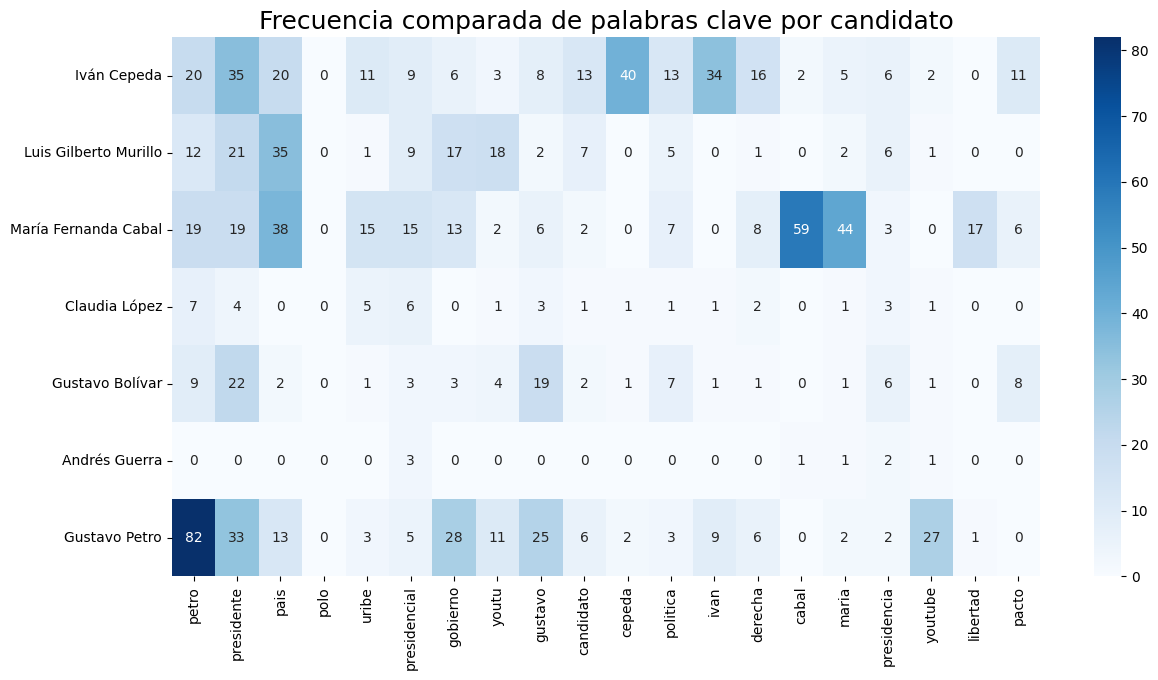

In [14]:
# matriz candidato x palabra
top_words = [w for w,_ in freq[:20]]

heat = pd.DataFrame(0, index=candidate_sources.keys(), columns=top_words)

for cand, sources in candidate_sources.items():
    toks = df[df["source"].isin(sources)]["tokens"].sum()
    cnt = Counter(toks)
    for w in top_words:
        heat.loc[cand, w] = cnt[w]

plt.figure(figsize=(14,7))
sns.heatmap(heat, annot=True, cmap="Blues")
plt.title("Frecuencia comparada de palabras clave por candidato", fontsize=18)
plt.show()
